# La Liga Score Analysis Report

This notebook analyzes Spanish La Liga team performance from 2010-11 to 2019-20 using cleaned and validated processed datasets.

The analysis focuses on score-based football metrics, including:

- league results
- scorelines
- points
- wins, draws and losses
- goals for and against
- home and away performance
- clean sheets
- failed-to-score matches
- team consistency across seasons

In [1]:
from pathlib import Path
import sys

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root configured successfully.")

Project root configured successfully.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR

# Seaborn theme for consistent report visuals
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Use the first color of the active Seaborn palette for single-series charts.
# Keeping this explicit also improves compatibility across Matplotlib versions.
BAR_COLOR = sns.color_palette()[0]

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename: str) -> None:
    """Save the current figure to outputs/figures."""
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: outputs/figures/{filename}")


## Load Processed Datasets

The analysis uses the processed datasets created by `01_data_preparation.ipynb`.

In [3]:
all_matches = pd.read_csv(
    PROCESSED_DATA_DIR / "all_matches.csv",
    parse_dates=["date"]
)

participations = pd.read_csv(
    PROCESSED_DATA_DIR / "participations.csv"
)

team_participation_counts = pd.read_csv(
    PROCESSED_DATA_DIR / "team_participation_counts.csv"
)

standings = pd.read_csv(
    PROCESSED_DATA_DIR / "standings.csv"
)

team_season_stats = pd.read_csv(
    PROCESSED_DATA_DIR / "team_season_stats.csv"
)

In [4]:
datasets = {
    "all_matches": all_matches,
    "participations": participations,
    "team_participation_counts": team_participation_counts,
    "standings": standings,
    "team_season_stats": team_season_stats,
}

dataset_summary = pd.DataFrame(
    {
        "dataset": list(datasets.keys()),
        "rows": [df.shape[0] for df in datasets.values()],
        "columns": [df.shape[1] for df in datasets.values()],
    }
)

dataset_summary

,dataset,rows,columns
0,all_matches,3800,12
1,participations,200,2
2,team_participation_counts,33,3
3,standings,200,12
4,team_season_stats,200,42


## Dataset Overview

The analysis covers 10 La Liga seasons from 2010-11 to 2019-20.

Each season includes:
- 20 teams
- 380 matches
- 38 matches per team

In [5]:
teams_per_season = (
    participations
    .groupby("season", as_index=False)
    .agg(teams=("team", "nunique"))
)

season_summary = (
    all_matches
    .groupby("season", as_index=False)
    .agg(
        matches=("season", "size"),
        first_match_date=("date", "min"),
        last_match_date=("date", "max"),
    )
    .merge(teams_per_season, on="season", how="left")
)

season_summary

,season,matches,first_match_date,last_match_date,teams
0,2010-11,380,2010-08-28,2011-05-21,20
1,2011-12,380,2011-08-27,2012-05-13,20
2,2012-13,380,2012-08-18,2013-06-01,20
3,2013-14,380,2013-08-17,2014-05-18,20
4,2014-15,380,2014-08-23,2015-05-23,20
5,2015-16,380,2015-08-21,2016-05-15,20
6,2016-17,380,2016-08-19,2017-05-21,20
7,2017-18,380,2017-08-18,2018-05-20,20
8,2018-19,380,2018-08-17,2019-05-19,20
9,2019-20,380,2019-08-16,2020-07-19,20


## Analytical Questions

This report focuses on the following questions:

1. What was the overall scoring profile of La Liga from 2010-11 to 2019-20?
2. Which scorelines were most common across the league?
3. How do scorelines differ between home and away team perspectives?
4. What were the most common scorelines for each team?
5. Which teams dominated the decade by total and average points?
6. Which teams were the most consistent across the full decade?
7. Which teams performed best at home and away?
8. Which teams had the strongest attacking output?
9. Which teams had the strongest defensive performance?
10. Which teams kept the most clean sheets?
11. Which were the best single seasons in the dataset?

## Decade Overview

This section summarizes the overall match and scoring profile of the dataset.

In [6]:
total_goals = all_matches["home_goals"].sum() + all_matches["away_goals"].sum()

decade_summary = pd.DataFrame(
    {
        "metric": [
            "Seasons",
            "Matches",
            "Goals",
            "Goals per match",
            "Home wins",
            "Draws",
            "Away wins",
        ],
        "value": [
            all_matches["season"].nunique(),
            len(all_matches),
            total_goals,
            round(total_goals / len(all_matches), 2),
            (all_matches["result"] == "H").sum(),
            (all_matches["result"] == "D").sum(),
            (all_matches["result"] == "A").sum(),
        ],
    }
)

decade_summary

,metric,value
0,Seasons,10.00
1,Matches,3800.00
2,Goals,10347.00
3,Goals per match,2.72
4,Home wins,1809.00
5,Draws,916.00
6,Away wins,1075.00


In [7]:
result_distribution = (
    all_matches["result"]
    .value_counts(normalize=False)
    .rename_axis("result")
    .reset_index(name="matches")
)

result_distribution["share_pct"] = (
    result_distribution["matches"] / len(all_matches) * 100
).round(1)

result_distribution

,result,matches,share_pct
0,H,1809,47.6
1,A,1075,28.3
2,D,916,24.1


## Scoreline Analysis

In [8]:
matches_scorelines = all_matches.copy()

# Raw scoreline from the home/away match perspective
matches_scorelines["scoreline"] = (
    matches_scorelines["home_goals"].astype(str)
    + "-"
    + matches_scorelines["away_goals"].astype(str)
)

matches_scorelines["total_goals"] = (
    matches_scorelines["home_goals"]
    + matches_scorelines["away_goals"]
)

matches_scorelines.head()

,season,date,home_team,away_team,home_goals,away_goals,result,source_file,home_team_official,away_team_official,expected_result,result_is_valid,scoreline,total_goals
0,2010-11,2010-08-28,Hercules,Ath Bilbao,0,1,A,2010-11_SP1.csv,Hércules CF,Athletic Bilbao,A,True,0-1,1
1,2010-11,2010-08-28,Levante,Sevilla,1,4,A,2010-11_SP1.csv,Levante UD,Sevilla FC,A,True,1-4,5
2,2010-11,2010-08-28,Malaga,Valencia,1,3,A,2010-11_SP1.csv,Málaga CF,Valencia CF,A,True,1-3,4
3,2010-11,2010-08-29,Espanol,Getafe,3,1,H,2010-11_SP1.csv,RCD Espanyol,Getafe CF,H,True,3-1,4
4,2010-11,2010-08-29,La Coruna,Zaragoza,0,0,D,2010-11_SP1.csv,Deportivo La Coruña,Real Zaragoza,D,True,0-0,0


In [9]:
scoreline_summary = (
    matches_scorelines
    .groupby("scoreline", as_index=False)
    .agg(matches=("scoreline", "size"))
    .sort_values("matches", ascending=False)
)

scoreline_summary["share_pct"] = (
    scoreline_summary["matches"] / len(matches_scorelines) * 100
).round(2)

scoreline_summary.head(10)

,scoreline,matches,share_pct
9,1-0,410,10.79
10,1-1,409,10.76
18,2-1,341,8.97
17,2-0,293,7.71
0,0-0,288,7.58
1,0-1,282,7.42
11,1-2,263,6.92
19,2-2,189,4.97
25,3-0,180,4.74
2,0-2,166,4.37


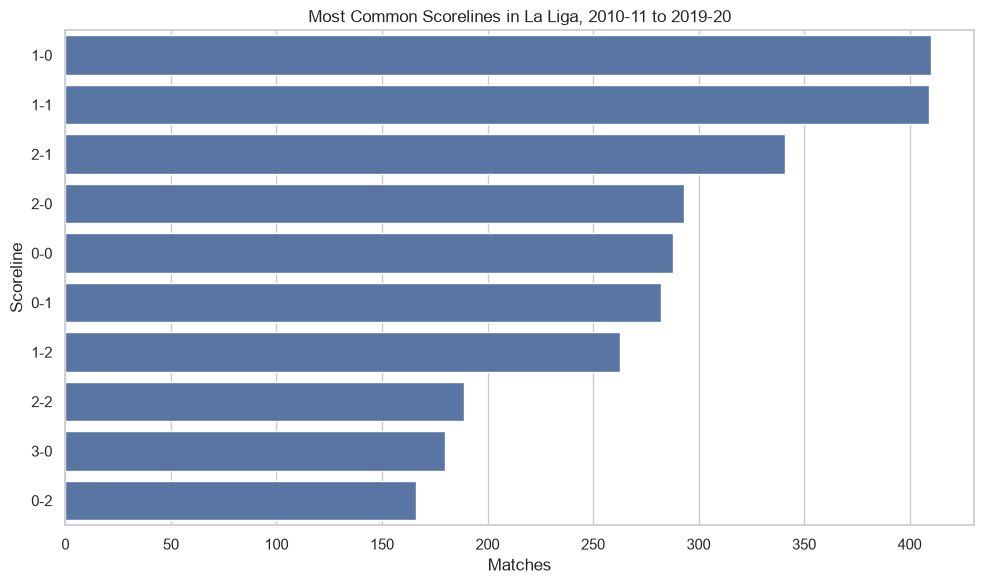

In [10]:
top_scorelines = (
    scoreline_summary
    .head(10)
    .sort_values("matches", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_scorelines,
    x="matches",
    y="scoreline",
    order=top_scorelines["scoreline"],
    color=BAR_COLOR
)
plt.title("Most Common Scorelines in La Liga, 2010-11 to 2019-20")
plt.xlabel("Matches")
plt.ylabel("Scoreline")
plt.tight_layout()
plt.show()

The most common scorelines provide a simple view of the league's typical match outcomes. Low-scoring results such as 1-0, 1-1 and 2-1 are expected to appear frequently in a large football dataset.

In [11]:
season_scorelines = (
    matches_scorelines
    .groupby(["season", "scoreline"], as_index=False)
    .agg(matches=("scoreline", "size"))
)

season_scorelines["season_max_matches"] = (
    season_scorelines
    .groupby("season")["matches"]
    .transform("max")
)

# Keep all joint-most-common scorelines when a season has a tie.
top_scoreline_by_season = (
    season_scorelines
    .loc[season_scorelines["matches"] == season_scorelines["season_max_matches"]]
    .drop(columns="season_max_matches")
    .sort_values(["season", "scoreline"])
    .reset_index(drop=True)
)

top_scoreline_by_season

,season,scoreline,matches
0,2010-11,1-0,48
1,2011-12,1-0,44
2,2012-13,1-0,40
3,2013-14,1-0,41
4,2014-15,1-1,43
5,2015-16,1-1,45
6,2016-17,1-1,43
7,2016-17,2-1,43
8,2017-18,1-0,48
9,2018-19,1-1,50


In [12]:
def goal_bucket(total_goals: int) -> str:
    """
    Categorize matches by total goals.
    """

    if total_goals == 0:
        return "0 goals"
    if total_goals == 1:
        return "1 goal"
    if total_goals == 2:
        return "2 goals"
    if total_goals == 3:
        return "3 goals"
    if total_goals == 4:
        return "4 goals"

    return "5+ goals"


matches_scorelines["goal_bucket"] = (
    matches_scorelines["total_goals"].apply(goal_bucket)
)

goal_bucket_summary = (
    matches_scorelines
    .groupby("goal_bucket", as_index=False)
    .agg(matches=("goal_bucket", "size"))
)

goal_bucket_order = [
    "0 goals",
    "1 goal",
    "2 goals",
    "3 goals",
    "4 goals",
    "5+ goals",
]

goal_bucket_summary["goal_bucket"] = pd.Categorical(
    goal_bucket_summary["goal_bucket"],
    categories=goal_bucket_order,
    ordered=True
)

goal_bucket_summary = goal_bucket_summary.sort_values("goal_bucket")

goal_bucket_summary["share_pct"] = (
    goal_bucket_summary["matches"] / len(matches_scorelines) * 100
).round(1)

goal_bucket_summary

,goal_bucket,matches,share_pct
0,0 goals,288,7.6
1,1 goal,692,18.2
2,2 goals,868,22.8
3,3 goals,854,22.5
4,4 goals,545,14.3
5,5+ goals,553,14.6


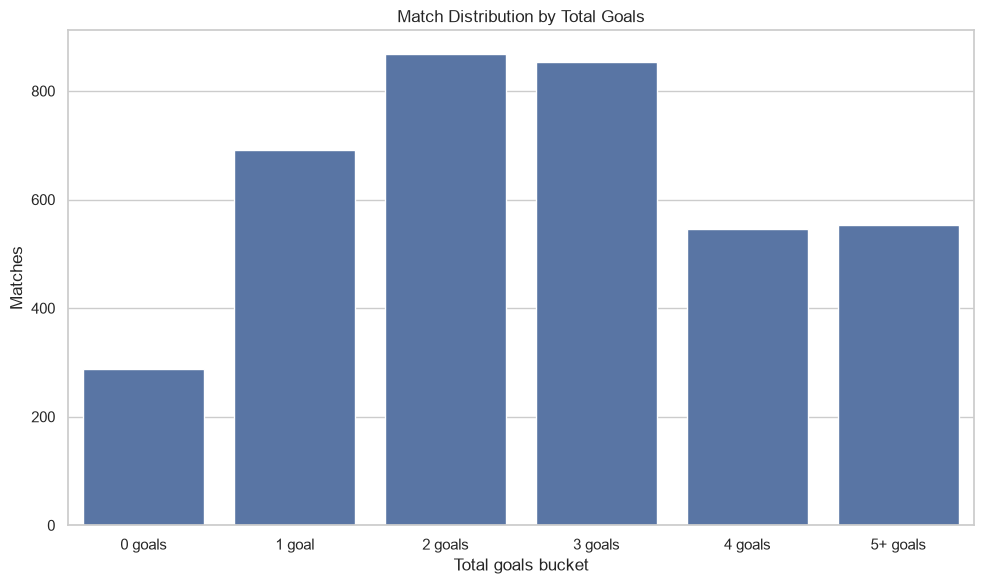

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=goal_bucket_summary,
    x="goal_bucket",
    y="matches",
    order=goal_bucket_order,
    color=BAR_COLOR
)
plt.title("Match Distribution by Total Goals")
plt.xlabel("Total goals bucket")
plt.ylabel("Matches")
plt.tight_layout()
plt.show()

In [14]:
home_team_scorelines = matches_scorelines[
    [
        "season",
        "date",
        "home_team",
        "home_team_official",
        "away_team",
        "away_team_official",
        "home_goals",
        "away_goals",
        "result",
    ]
].copy()

home_team_scorelines = home_team_scorelines.rename(
    columns={
        "home_team": "team",
        "home_team_official": "team_official",
        "away_team": "opponent",
        "away_team_official": "opponent_official",
        "home_goals": "goals_for",
        "away_goals": "goals_against",
    }
)

home_team_scorelines["venue"] = "home"

away_team_scorelines = matches_scorelines[
    [
        "season",
        "date",
        "away_team",
        "away_team_official",
        "home_team",
        "home_team_official",
        "away_goals",
        "home_goals",
        "result",
    ]
].copy()

away_team_scorelines = away_team_scorelines.rename(
    columns={
        "away_team": "team",
        "away_team_official": "team_official",
        "home_team": "opponent",
        "home_team_official": "opponent_official",
        "away_goals": "goals_for",
        "home_goals": "goals_against",
    }
)

away_team_scorelines["venue"] = "away"

team_scorelines = pd.concat(
    [home_team_scorelines, away_team_scorelines],
    ignore_index=True
)

team_scorelines["team_scoreline"] = (
    team_scorelines["goals_for"].astype(str)
    + "-"
    + team_scorelines["goals_against"].astype(str)
)

team_scorelines["outcome"] = "D"
team_scorelines.loc[
    team_scorelines["goals_for"] > team_scorelines["goals_against"],
    "outcome"
] = "W"
team_scorelines.loc[
    team_scorelines["goals_for"] < team_scorelines["goals_against"],
    "outcome"
] = "L"

team_scorelines.head()

,season,date,team,team_official,opponent,opponent_official,goals_for,goals_against,result,venue,team_scoreline,outcome
0,2010-11,2010-08-28,Hercules,Hércules CF,Ath Bilbao,Athletic Bilbao,0,1,A,home,0-1,L
1,2010-11,2010-08-28,Levante,Levante UD,Sevilla,Sevilla FC,1,4,A,home,1-4,L
2,2010-11,2010-08-28,Malaga,Málaga CF,Valencia,Valencia CF,1,3,A,home,1-3,L
3,2010-11,2010-08-29,Espanol,RCD Espanyol,Getafe,Getafe CF,3,1,H,home,3-1,W
4,2010-11,2010-08-29,La Coruna,Deportivo La Coruña,Zaragoza,Real Zaragoza,0,0,D,home,0-0,D


In [15]:
assert team_scorelines.shape[0] == all_matches.shape[0] * 2
assert team_scorelines["team_official"].notna().all()

In [16]:
team_scoreline_summary = (
    team_scorelines
    .groupby("team_scoreline", as_index=False)
    .agg(team_matches=("team_scoreline", "size"))
    .sort_values("team_matches", ascending=False)
)

team_scoreline_summary["share_pct"] = (
    team_scoreline_summary["team_matches"] / len(team_scorelines) * 100
).round(2)

team_scoreline_summary.head(10)

,team_scoreline,team_matches,share_pct
10,1-1,818,10.76
9,1-0,692,9.11
1,0-1,692,9.11
11,1-2,604,7.95
21,2-1,604,7.95
0,0-0,576,7.58
2,0-2,459,6.04
20,2-0,459,6.04
23,2-2,378,4.97
3,0-3,250,3.29


In [17]:
team_scoreline_counts = (
    team_scorelines
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(matches=("team_scoreline", "size"))
)

team_scoreline_counts["team_max_matches"] = (
    team_scoreline_counts
    .groupby(["team", "team_official"])["matches"]
    .transform("max")
)

# Keep all joint-top scorelines instead of selecting one arbitrarily.
team_top_scorelines = (
    team_scoreline_counts
    .loc[team_scoreline_counts["matches"] == team_scoreline_counts["team_max_matches"]]
    .drop(columns="team_max_matches")
    .sort_values(["matches", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_scorelines.head(20)

,team,team_official,team_scoreline,matches
0,Ath Madrid,Club Atlético de Madrid,1-0,64
1,Valencia,Valencia CF,1-1,51
2,Ath Bilbao,Athletic Bilbao,1-1,50
3,Malaga,Málaga CF,0-1,43
4,Sevilla,Sevilla FC,1-1,43
5,Espanol,RCD Espanyol,1-0,42
6,Sociedad,Real Sociedad,1-1,42
7,Getafe,Getafe CF,1-1,41
8,Barcelona,FC Barcelona,2-1,39
9,Levante,Levante UD,1-1,39


In [18]:
team_home_scoreline_counts = (
    team_scorelines
    .loc[team_scorelines["venue"] == "home"]
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(matches=("team_scoreline", "size"))
)

team_home_scoreline_counts["team_max_matches"] = (
    team_home_scoreline_counts
    .groupby(["team", "team_official"])["matches"]
    .transform("max")
)

team_top_home_scorelines = (
    team_home_scoreline_counts
    .loc[team_home_scoreline_counts["matches"] == team_home_scoreline_counts["team_max_matches"]]
    .drop(columns="team_max_matches")
    .sort_values(["matches", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_home_scorelines.head(20)

,team,team_official,team_scoreline,matches
0,Ath Madrid,Club Atlético de Madrid,1-0,32
1,Espanol,RCD Espanyol,1-0,30
2,Ath Bilbao,Athletic Bilbao,1-1,29
3,Valencia,Valencia CF,2-1,27
4,Real Madrid,Real Madrid CF,2-0,24
5,Celta,RC Celta de Vigo,1-1,23
6,Sociedad,Real Sociedad,1-1,23
7,Sevilla,Sevilla FC,1-0,23
8,Sevilla,Sevilla FC,2-0,23
9,Barcelona,FC Barcelona,2-1,22


In [19]:
team_away_scoreline_counts = (
    team_scorelines
    .loc[team_scorelines["venue"] == "away"]
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(matches=("team_scoreline", "size"))
)

team_away_scoreline_counts["team_max_matches"] = (
    team_away_scoreline_counts
    .groupby(["team", "team_official"])["matches"]
    .transform("max")
)

team_top_away_scorelines = (
    team_away_scoreline_counts
    .loc[team_away_scoreline_counts["matches"] == team_away_scoreline_counts["team_max_matches"]]
    .drop(columns="team_max_matches")
    .sort_values(["matches", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_away_scorelines.head(20)

,team,team_official,team_scoreline,matches
0,Ath Madrid,Club Atlético de Madrid,1-0,32
1,Malaga,Málaga CF,0-1,27
2,Valencia,Valencia CF,1-1,27
3,Real Madrid,Real Madrid CF,2-1,26
4,Sevilla,Sevilla FC,1-1,25
5,Getafe,Getafe CF,0-2,24
6,Espanol,RCD Espanyol,0-1,24
7,Betis,Real Betis Balompié,0-1,24
8,Celta,RC Celta de Vigo,1-2,22
9,Ath Bilbao,Athletic Bilbao,0-2,21


In [20]:
winning_scorelines = (
    team_scorelines
    .loc[team_scorelines["outcome"] == "W"]
    .groupby("team_scoreline", as_index=False)
    .agg(wins=("team_scoreline", "size"))
    .sort_values("wins", ascending=False)
)

winning_scorelines["share_pct"] = (
    winning_scorelines["wins"] / winning_scorelines["wins"].sum() * 100
).round(2)

winning_scorelines.head(10)

,team_scoreline,wins,share_pct
0,1-0,692,23.99
3,2-1,604,20.94
2,2-0,459,15.92
4,3-0,250,8.67
5,3-1,237,8.22
6,3-2,147,5.10
7,4-0,119,4.13
8,4-1,99,3.43
9,4-2,63,2.18
11,5-0,56,1.94


In [21]:
team_winning_scoreline_counts = (
    team_scorelines
    .loc[team_scorelines["outcome"] == "W"]
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(wins=("team_scoreline", "size"))
)

team_winning_scoreline_counts["team_max_wins"] = (
    team_winning_scoreline_counts
    .groupby(["team", "team_official"])["wins"]
    .transform("max")
)

team_top_winning_scorelines = (
    team_winning_scoreline_counts
    .loc[team_winning_scoreline_counts["wins"] == team_winning_scoreline_counts["team_max_wins"]]
    .drop(columns="team_max_wins")
    .sort_values(["wins", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_winning_scorelines.head(20)

,team,team_official,team_scoreline,wins
0,Ath Madrid,Club Atlético de Madrid,1-0,64
1,Valencia,Valencia CF,2-1,47
2,Espanol,RCD Espanyol,1-0,42
3,Ath Bilbao,Athletic Bilbao,2-1,40
4,Barcelona,FC Barcelona,2-1,39
5,Real Madrid,Real Madrid CF,2-1,39
6,Villarreal,Villarreal CF,1-0,38
7,Sevilla,Sevilla FC,1-0,36
8,Sociedad,Real Sociedad,1-0,32
9,Getafe,Getafe CF,1-0,31


In [22]:
team_home_winning_scoreline_counts = (
    team_scorelines
    .loc[
        (team_scorelines["outcome"] == "W")
        & (team_scorelines["venue"] == "home")
    ]
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(wins=("team_scoreline", "size"))
)

team_home_winning_scoreline_counts["team_max_wins"] = (
    team_home_winning_scoreline_counts
    .groupby(["team", "team_official"])["wins"]
    .transform("max")
)

team_top_home_winning_scorelines = (
    team_home_winning_scoreline_counts
    .loc[team_home_winning_scoreline_counts["wins"] == team_home_winning_scoreline_counts["team_max_wins"]]
    .drop(columns="team_max_wins")
    .sort_values(["wins", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_home_winning_scorelines.head(20)

,team,team_official,team_scoreline,wins
0,Ath Madrid,Club Atlético de Madrid,1-0,32
1,Espanol,RCD Espanyol,1-0,30
2,Valencia,Valencia CF,2-1,27
3,Real Madrid,Real Madrid CF,2-0,24
4,Ath Bilbao,Athletic Bilbao,1-0,23
5,Sevilla,Sevilla FC,1-0,23
6,Sevilla,Sevilla FC,2-0,23
7,Barcelona,FC Barcelona,2-1,22
8,Getafe,Getafe CF,1-0,22
9,Levante,Levante UD,2-1,19


In [23]:
team_away_winning_scoreline_counts = (
    team_scorelines
    .loc[
        (team_scorelines["outcome"] == "W")
        & (team_scorelines["venue"] == "away")
    ]
    .groupby(["team", "team_official", "team_scoreline"], as_index=False)
    .agg(wins=("team_scoreline", "size"))
)

team_away_winning_scoreline_counts["team_max_wins"] = (
    team_away_winning_scoreline_counts
    .groupby(["team", "team_official"])["wins"]
    .transform("max")
)

team_top_away_winning_scorelines = (
    team_away_winning_scoreline_counts
    .loc[team_away_winning_scoreline_counts["wins"] == team_away_winning_scoreline_counts["team_max_wins"]]
    .drop(columns="team_max_wins")
    .sort_values(["wins", "team_official", "team_scoreline"], ascending=[False, True, True])
    .reset_index(drop=True)
)

team_top_away_winning_scorelines.head(20)

,team,team_official,team_scoreline,wins
0,Ath Madrid,Club Atlético de Madrid,1-0,32
1,Real Madrid,Real Madrid CF,2-1,26
2,Barcelona,FC Barcelona,2-0,20
3,Valencia,Valencia CF,2-1,20
4,Ath Bilbao,Athletic Bilbao,2-1,19
5,Villarreal,Villarreal CF,1-0,19
6,Getafe,Getafe CF,2-1,18
7,Sociedad,Real Sociedad,1-0,14
8,Levante,Levante UD,1-0,13
9,Celta,RC Celta de Vigo,1-0,13


### Analyst Comment

The decade overview and scoreline sections establish the league-wide baseline before team comparisons. Raw scorelines preserve the home/away match perspective, while team-perspective scorelines allow the same outcome to be interpreted consistently for a club regardless of venue.

## Team Dominance Analysis

This section analyzes which teams dominated La Liga between 2010-11 and 2019-20.

The first view looks at total points across the decade. This rewards both performance and long-term presence in La Liga, so it should be interpreted together with the number of seasons played.

In [24]:
decade_points = (
    standings
    .groupby(["team", "team_official"], as_index=False)
    .agg(
        seasons_played=("season", "nunique"),
        total_points=("points", "sum"),
        avg_points_per_season=("points", "mean"),
        best_points=("points", "max"),
        worst_points=("points", "min"),
        avg_position=("position", "mean"),
        best_position=("position", "min"),
        worst_position=("position", "max"),
    )
    .sort_values("total_points", ascending=False)
    .reset_index(drop=True)
)

decade_points.head(15)

,team,team_official,seasons_played,total_points,avg_points_per_season,best_points,worst_points,avg_position,best_position,worst_position
0,Barcelona,FC Barcelona,10,911,91.100000,100,82,1.400000,1,2
1,Real Madrid,Real Madrid CF,10,870,87.000000,100,68,2.000000,1,3
2,Ath Madrid,Club Atlético de Madrid,10,749,74.900000,90,56,3.000000,1,5
3,Sevilla,Sevilla FC,10,608,60.800000,76,50,6.200000,4,9
4,Valencia,Valencia CF,10,600,60.000000,77,44,6.300000,3,12
5,Ath Bilbao,Athletic Bilbao,10,549,54.900000,70,43,8.600000,4,16
6,Sociedad,Real Sociedad,10,530,53.000000,66,45,9.000000,4,15
7,Villarreal,Villarreal CF,9,518,57.555556,67,41,7.444444,4,18
8,Espanol,RCD Espanyol,10,456,45.600000,56,25,12.000000,7,20
9,Getafe,Getafe CF,9,421,46.777778,59,36,12.000000,6,19


Saved figure: outputs/figures/top_10_total_points.png


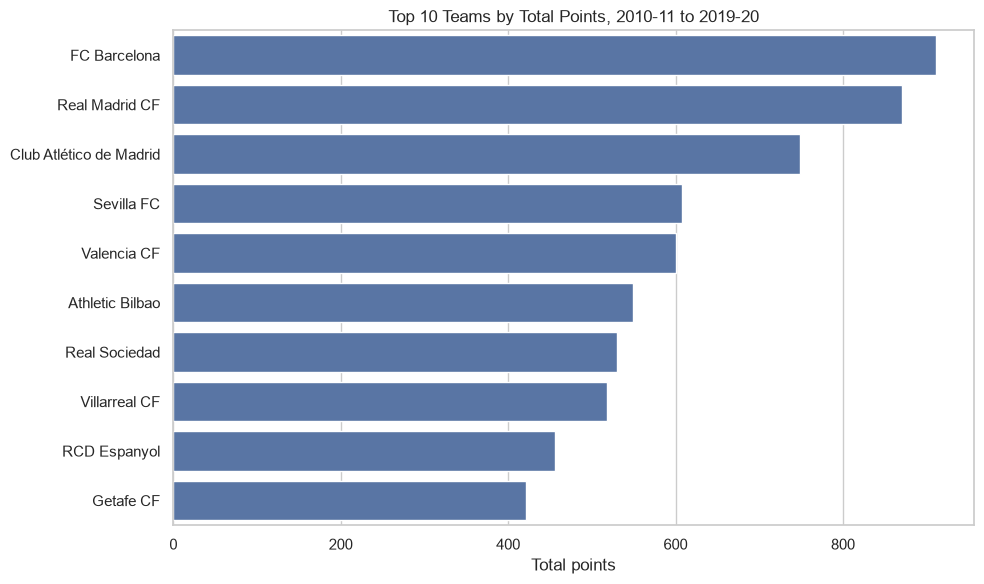

In [25]:
top_total_points = (
    decade_points
    .head(10)
    .sort_values("total_points", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_total_points,
    x="total_points",
    y="team_official",
    order=top_total_points["team_official"],
    color=BAR_COLOR
)
plt.title("Top 10 Teams by Total Points, 2010-11 to 2019-20")
plt.xlabel("Total points")
plt.ylabel("")
plt.tight_layout()
save_current_figure("top_10_total_points.png")
plt.show()

Total points highlight long-term dominance, but they are affected by the number of seasons each team played in La Liga. For that reason, average points per season is analyzed next.

In [26]:
avg_points_ranking = (
    decade_points
    .loc[decade_points["seasons_played"] >= 3]
    .sort_values("avg_points_per_season", ascending=False)
    .reset_index(drop=True)
)

avg_points_ranking.head(15)

,team,team_official,seasons_played,total_points,avg_points_per_season,best_points,worst_points,avg_position,best_position,worst_position
0,Barcelona,FC Barcelona,10,911,91.100000,100,82,1.400000,1,2
1,Real Madrid,Real Madrid CF,10,870,87.000000,100,68,2.000000,1,3
2,Ath Madrid,Club Atlético de Madrid,10,749,74.900000,90,56,3.000000,1,5
3,Sevilla,Sevilla FC,10,608,60.800000,76,50,6.200000,4,9
4,Valencia,Valencia CF,10,600,60.000000,77,44,6.300000,3,12
5,Villarreal,Villarreal CF,9,518,57.555556,67,41,7.444444,4,18
6,Ath Bilbao,Athletic Bilbao,10,549,54.900000,70,43,8.600000,4,16
7,Sociedad,Real Sociedad,10,530,53.000000,66,45,9.000000,4,15
8,Alaves,Deportivo Alavés,4,191,47.750000,55,39,12.500000,9,16
9,Getafe,Getafe CF,9,421,46.777778,59,36,12.000000,6,19


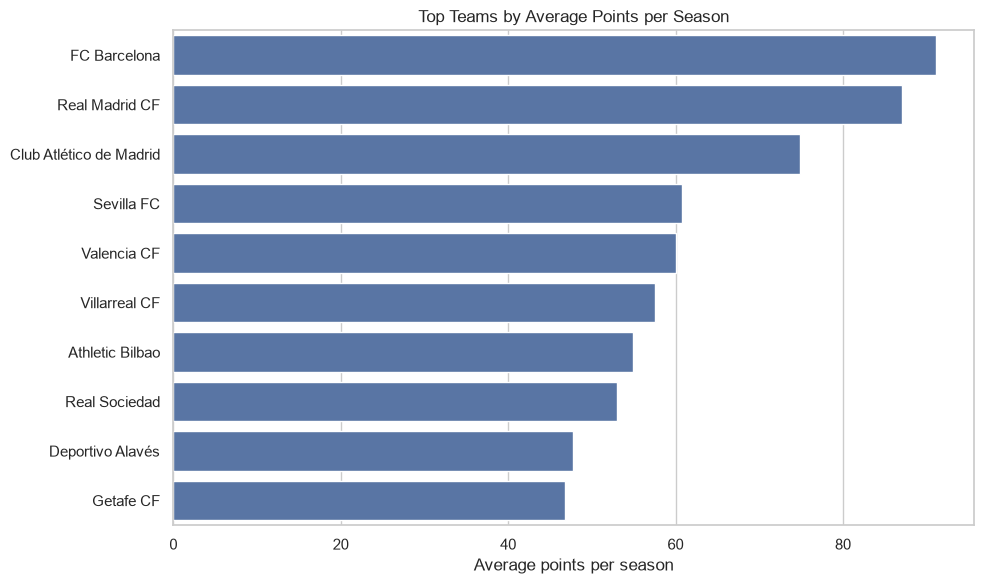

In [27]:
top_avg_points = (
    avg_points_ranking
    .head(10)
    .sort_values("avg_points_per_season", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_avg_points,
    x="avg_points_per_season",
    y="team_official",
    order=top_avg_points["team_official"],
    color=BAR_COLOR
)
plt.title("Top Teams by Average Points per Season")
plt.xlabel("Average points per season")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Analyst Comment

Total points highlight long-term dominance but also reward continuous participation. Average points per season provides a complementary view of team strength when clubs have different numbers of seasons in the dataset.

## Consistency Across Seasons

Total points show dominance, but consistency requires looking at season-by-season performance.

This section focuses on teams that played all 10 seasons in the dataset and compares their average points, best season, worst season and average position.

In [28]:
full_decade_teams = (
    decade_points
    .loc[decade_points["seasons_played"] == 10]
    .sort_values("avg_points_per_season", ascending=False)
    .reset_index(drop=True)
)

full_decade_teams

,team,team_official,seasons_played,total_points,avg_points_per_season,best_points,worst_points,avg_position,best_position,worst_position
0,Barcelona,FC Barcelona,10,911,91.1,100,82,1.4,1,2
1,Real Madrid,Real Madrid CF,10,870,87.0,100,68,2.0,1,3
2,Ath Madrid,Club Atlético de Madrid,10,749,74.9,90,56,3.0,1,5
3,Sevilla,Sevilla FC,10,608,60.8,76,50,6.2,4,9
4,Valencia,Valencia CF,10,600,60.0,77,44,6.3,3,12
5,Ath Bilbao,Athletic Bilbao,10,549,54.9,70,43,8.6,4,16
6,Sociedad,Real Sociedad,10,530,53.0,66,45,9.0,4,15
7,Espanol,RCD Espanyol,10,456,45.6,56,25,12.0,7,20


In [29]:
full_decade_consistency = full_decade_teams[
    [
        "team_official",
        "total_points",
        "avg_points_per_season",
        "best_points",
        "worst_points",
        "avg_position",
        "best_position",
        "worst_position",
    ]
].copy()

full_decade_consistency["points_range"] = (
    full_decade_consistency["best_points"]
    - full_decade_consistency["worst_points"]
)

full_decade_consistency = full_decade_consistency.sort_values(
    ["avg_points_per_season", "worst_position"],
    ascending=[False, True]
)

full_decade_consistency

,team_official,total_points,avg_points_per_season,best_points,worst_points,avg_position,best_position,worst_position,points_range
0,FC Barcelona,911,91.1,100,82,1.4,1,2,18
1,Real Madrid CF,870,87.0,100,68,2.0,1,3,32
2,Club Atlético de Madrid,749,74.9,90,56,3.0,1,5,34
3,Sevilla FC,608,60.8,76,50,6.2,4,9,26
4,Valencia CF,600,60.0,77,44,6.3,3,12,33
5,Athletic Bilbao,549,54.9,70,43,8.6,4,16,27
6,Real Sociedad,530,53.0,66,45,9.0,4,15,21
7,RCD Espanyol,456,45.6,56,25,12.0,7,20,31


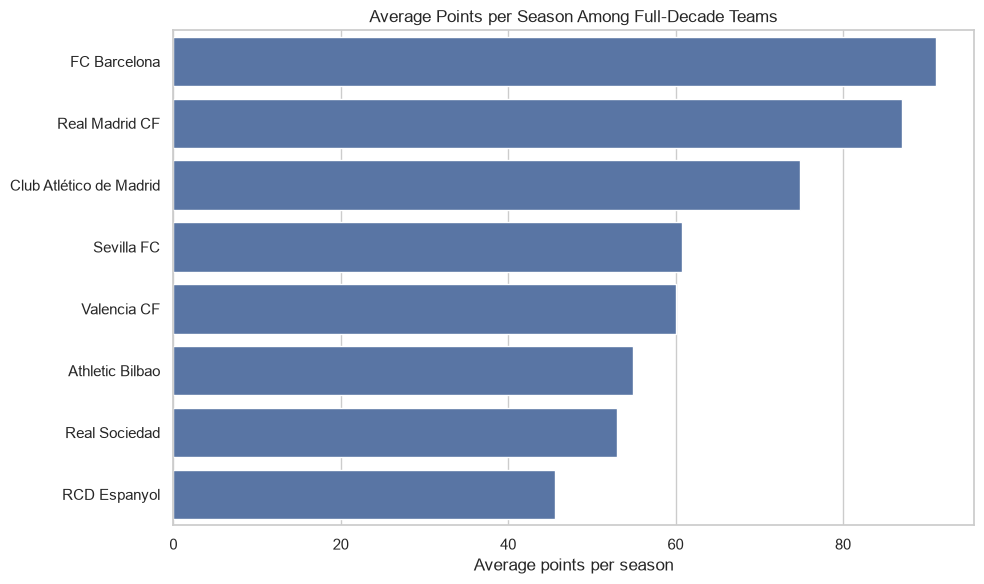

In [30]:
plot_data = (
    full_decade_consistency
    .sort_values("avg_points_per_season", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="avg_points_per_season",
    y="team_official",
    order=plot_data["team_official"],
    color=BAR_COLOR
)
plt.title("Average Points per Season Among Full-Decade Teams")
plt.xlabel("Average points per season")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [31]:
top_full_decade_team_names = (
    full_decade_teams
    .head(6)["team"]
    .tolist()
)

points_trend = standings.loc[
    standings["team"].isin(top_full_decade_team_names),
    ["season", "team", "team_official", "points"]
].copy()

points_trend.head()

,season,team,team_official,points
0,2010-11,Barcelona,FC Barcelona,96
1,2010-11,Real Madrid,Real Madrid CF,92
2,2010-11,Valencia,Valencia CF,71
4,2010-11,Ath Madrid,Club Atlético de Madrid,58
5,2010-11,Ath Bilbao,Athletic Bilbao,58


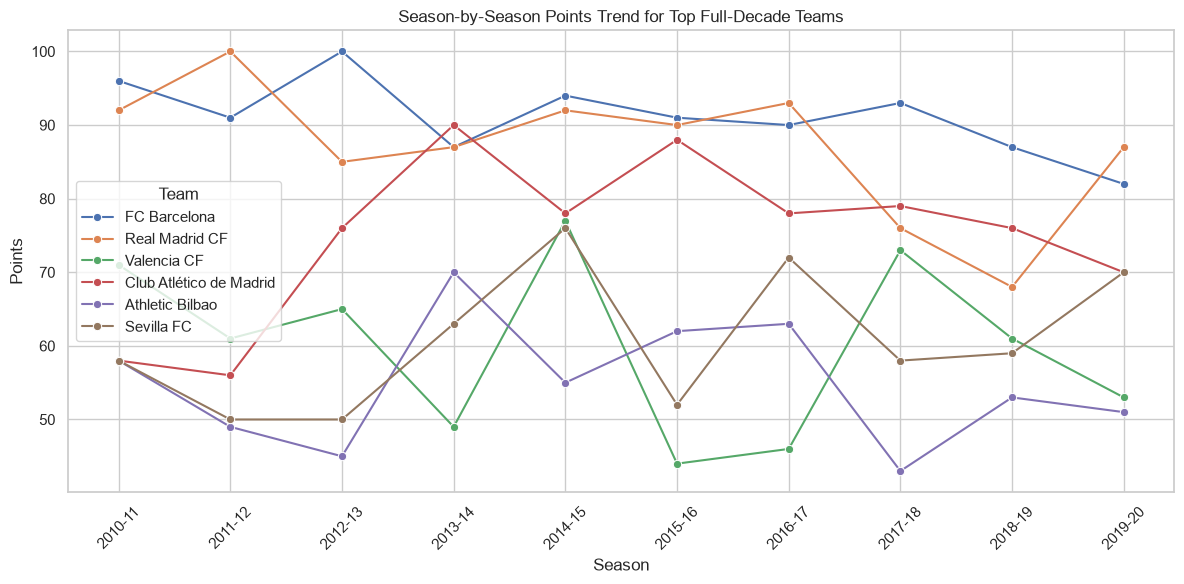

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=points_trend,
    x="season",
    y="points",
    hue="team_official",
    marker="o"
)
plt.title("Season-by-Season Points Trend for Top Full-Decade Teams")
plt.xlabel("Season")
plt.ylabel("Points")
plt.xticks(rotation=45)
plt.legend(title="Team")
plt.tight_layout()
plt.show()

The season-by-season trend helps distinguish sustained dominance from single-season peaks. It also shows whether a team maintained a stable level or had large performance swings across the decade.

### Analyst Comment

Restricting the consistency analysis to teams present in all 10 seasons creates a fairer long-term comparison. Season-by-season trends help separate sustained elite performance from short-lived peaks.

## Home vs Away Performance

Football performance is often strongly affected by venue. This section compares home and away points-per-match across teams.

The analysis uses team-season statistics aggregated across the decade.

In [33]:
home_away_summary = (
    team_season_stats
    .groupby(["team", "team_official"], as_index=False)
    .agg(
        seasons_played=("season", "nunique"),
        home_points=("home_points", "sum"),
        away_points=("away_points", "sum"),
        home_matches=("home_matches", "sum"),
        away_matches=("away_matches", "sum"),
        home_wins=("home_wins", "sum"),
        away_wins=("away_wins", "sum"),
        home_goals_for=("home_goals_for", "sum"),
        away_goals_for=("away_goals_for", "sum"),
        home_goals_against=("home_goals_against", "sum"),
        away_goals_against=("away_goals_against", "sum"),
    )
)

home_away_summary["home_ppm"] = (
    home_away_summary["home_points"]
    / home_away_summary["home_matches"]
).round(2)

home_away_summary["away_ppm"] = (
    home_away_summary["away_points"]
    / home_away_summary["away_matches"]
).round(2)

home_away_summary["home_away_ppm_gap"] = (
    home_away_summary["home_ppm"]
    - home_away_summary["away_ppm"]
).round(2)

home_away_summary["home_win_rate"] = (
    home_away_summary["home_wins"]
    / home_away_summary["home_matches"]
    * 100
).round(1)

home_away_summary["away_win_rate"] = (
    home_away_summary["away_wins"]
    / home_away_summary["away_matches"]
    * 100
).round(1)

home_away_summary.head()

,team,team_official,seasons_played,home_points,away_points,home_matches,away_matches,home_wins,away_wins,home_goals_for,away_goals_for,home_goals_against,away_goals_against,home_ppm,away_ppm,home_away_ppm_gap,home_win_rate,away_win_rate
0,Alaves,Deportivo Alavés,4,113,78,76,76,30,22,79,75,82,120,1.49,1.03,0.46,39.5,28.9
1,Almeria,UD Almería,3,59,43,57,57,12,13,69,45,94,111,1.04,0.75,0.29,21.1,22.8
2,Ath Bilbao,Athletic Bilbao,10,340,209,190,190,97,53,290,204,190,282,1.79,1.10,0.69,51.1,27.9
3,Ath Madrid,Club Atlético de Madrid,10,433,316,190,190,132,88,367,254,120,188,2.28,1.66,0.62,69.5,46.3
4,Barcelona,FC Barcelona,10,502,409,190,190,161,122,597,440,137,176,2.64,2.15,0.49,84.7,64.2


In [34]:
best_home_teams = (
    home_away_summary
    .loc[home_away_summary["seasons_played"] >= 3]
    .sort_values("home_ppm", ascending=False)
    .reset_index(drop=True)
)

best_home_teams[
    [
        "team_official",
        "seasons_played",
        "home_matches",
        "home_points",
        "home_ppm",
        "home_win_rate",
    ]
].head(10)

,team_official,seasons_played,home_matches,home_points,home_ppm,home_win_rate
0,FC Barcelona,10,190,502,2.64,84.7
1,Real Madrid CF,10,190,475,2.50,79.5
2,Club Atlético de Madrid,10,190,433,2.28,69.5
3,Sevilla FC,10,190,389,2.05,61.6
4,Valencia CF,10,190,361,1.90,54.7
5,Villarreal CF,9,171,308,1.80,51.5
6,Athletic Bilbao,10,190,340,1.79,51.1
7,Real Sociedad,10,190,326,1.72,48.9
8,Málaga CF,8,152,234,1.54,44.7
9,RCD Mallorca,4,76,116,1.53,43.4


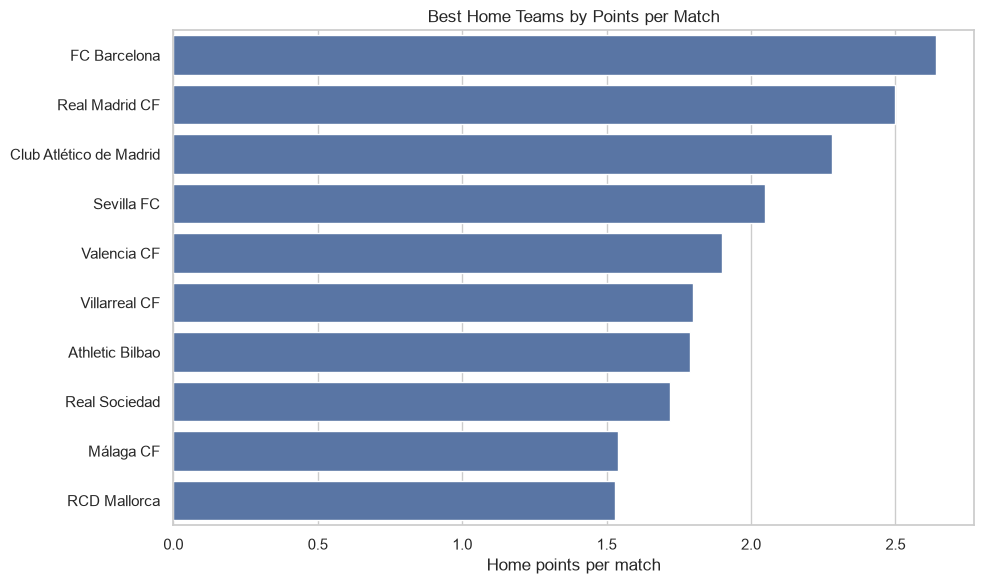

In [35]:
plot_data = (
    best_home_teams
    .head(10)
    .sort_values("home_ppm", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="home_ppm",
    y="team_official",
    order=plot_data["team_official"],
    color=BAR_COLOR
)
plt.title("Best Home Teams by Points per Match")
plt.xlabel("Home points per match")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [36]:
best_away_teams = (
    home_away_summary
    .loc[home_away_summary["seasons_played"] >= 3]
    .sort_values("away_ppm", ascending=False)
    .reset_index(drop=True)
)

best_away_teams[
    [
        "team_official",
        "seasons_played",
        "away_matches",
        "away_points",
        "away_ppm",
        "away_win_rate",
    ]
].head(10)

,team_official,seasons_played,away_matches,away_points,away_ppm,away_win_rate
0,FC Barcelona,10,190,409,2.15,64.2
1,Real Madrid CF,10,190,395,2.08,62.6
2,Club Atlético de Madrid,10,190,316,1.66,46.3
3,Valencia CF,10,190,239,1.26,33.2
4,Villarreal CF,9,171,210,1.23,32.2
5,Sevilla FC,10,190,219,1.15,29.5
6,Athletic Bilbao,10,190,209,1.10,27.9
7,Real Sociedad,10,190,204,1.07,27.9
8,Deportivo Alavés,4,76,78,1.03,28.9
9,Getafe CF,9,171,161,0.94,22.8


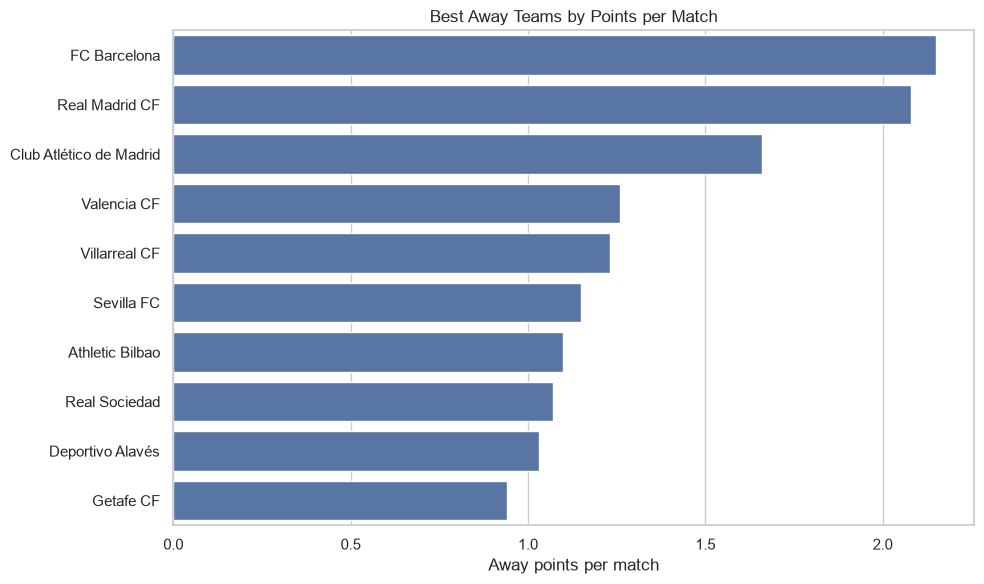

In [37]:
plot_data = (
    best_away_teams
    .head(10)
    .sort_values("away_ppm", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="away_ppm",
    y="team_official",
    order=plot_data["team_official"],
    color=BAR_COLOR
)
plt.title("Best Away Teams by Points per Match")
plt.xlabel("Away points per match")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [38]:
largest_home_advantage = (
    home_away_summary
    .loc[home_away_summary["seasons_played"] >= 3]
    .sort_values("home_away_ppm_gap", ascending=False)
    .reset_index(drop=True)
)

largest_home_advantage[
    [
        "team_official",
        "seasons_played",
        "home_ppm",
        "away_ppm",
        "home_away_ppm_gap",
    ]
].head(10)

,team_official,seasons_played,home_ppm,away_ppm,home_away_ppm_gap
0,Sevilla FC,10,2.05,1.15,0.90
1,RCD Mallorca,4,1.53,0.64,0.89
2,UD Las Palmas,3,1.33,0.51,0.82
3,Athletic Bilbao,10,1.79,1.10,0.69
4,Sporting Gijón,4,1.34,0.68,0.66
5,Real Sociedad,10,1.72,1.07,0.65
6,Málaga CF,8,1.54,0.89,0.65
7,Levante UD,9,1.50,0.85,0.65
8,Valencia CF,10,1.90,1.26,0.64
9,RCD Espanyol,10,1.51,0.89,0.62


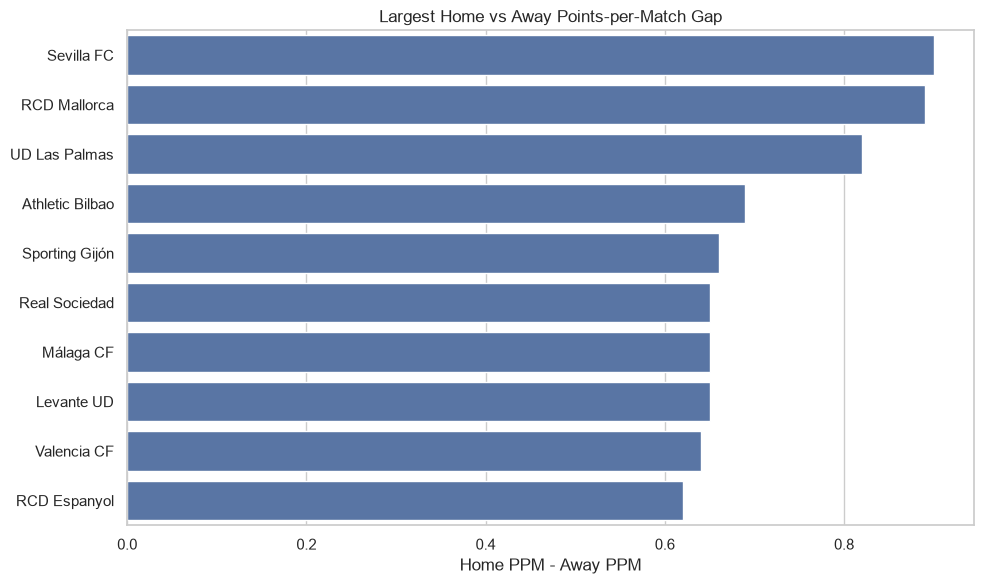

In [39]:
plot_data = (
    largest_home_advantage
    .head(10)
    .sort_values("home_away_ppm_gap", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="home_away_ppm_gap",
    y="team_official",
    order=plot_data["team_official"],
    color=BAR_COLOR
)
plt.title("Largest Home vs Away Points-per-Match Gap")
plt.xlabel("Home PPM - Away PPM")
plt.ylabel("")
plt.tight_layout()
plt.show()

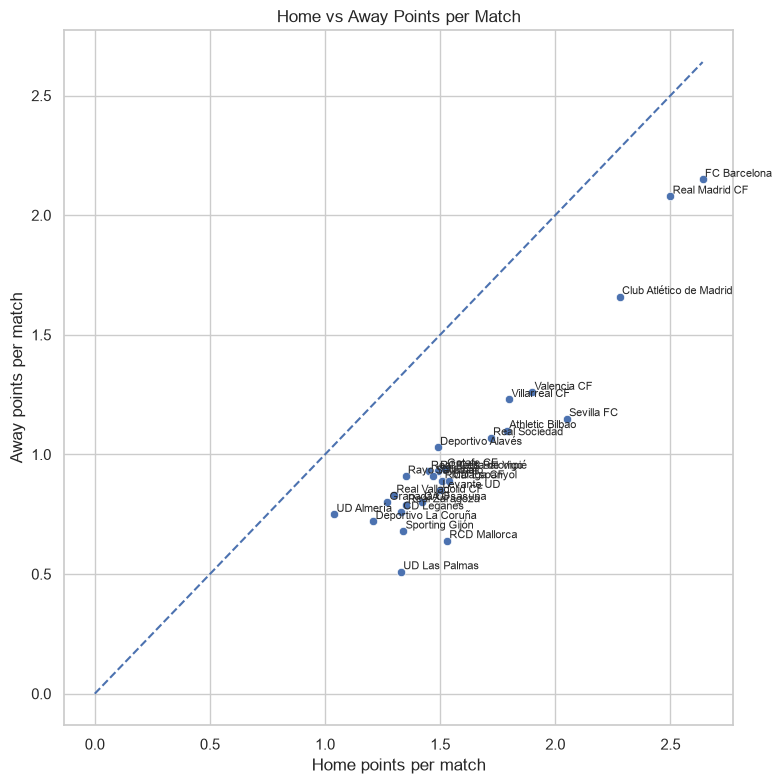

In [40]:
scatter_data = home_away_summary.loc[
    home_away_summary["seasons_played"] >= 3
].copy()

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=scatter_data,
    x="home_ppm",
    y="away_ppm"
)

for _, row in scatter_data.iterrows():
    plt.text(
        row["home_ppm"] + 0.01,
        row["away_ppm"] + 0.01,
        row["team_official"],
        fontsize=8
    )

max_ppm = max(
    scatter_data["home_ppm"].max(),
    scatter_data["away_ppm"].max()
)

plt.plot([0, max_ppm], [0, max_ppm], linestyle="--")

plt.title("Home vs Away Points per Match")
plt.xlabel("Home points per match")
plt.ylabel("Away points per match")
plt.tight_layout()
plt.show()

Teams above the diagonal collected more points per match away than at home, while teams below the diagonal were stronger at home. Most teams are expected to sit below the diagonal, reflecting the typical home advantage in football.

### Analyst Comment

Home and away points per match show how strongly venue affected team performance. A smaller home-away gap suggests less dependence on home advantage, while a large positive gap indicates substantially stronger home results.

## Attacking Performance

This section analyzes attacking output across the decade.

The main metrics are total goals scored, goals per match, home/away scoring rates and peak single-season attacking output. Team-level decade rankings use a minimum threshold of 3 seasons played to reduce small-sample effects.

In [41]:
attack_summary = (
    team_season_stats
    .groupby(["team", "team_official"], as_index=False)
    .agg(
        seasons_played=("season", "nunique"),
        matches=("matches", "sum"),
        goals_for=("goals_for", "sum"),
        home_matches=("home_matches", "sum"),
        away_matches=("away_matches", "sum"),
        home_goals_for=("home_goals_for", "sum"),
        away_goals_for=("away_goals_for", "sum"),
        max_goals_in_season=("goals_for", "max"),
        avg_goals_per_season=("goals_for", "mean"),
    )
)

attack_summary["goals_for_per_match"] = (
    attack_summary["goals_for"] / attack_summary["matches"]
).round(2)

attack_summary["home_goals_for_per_match"] = (
    attack_summary["home_goals_for"] / attack_summary["home_matches"]
).round(2)

attack_summary["away_goals_for_per_match"] = (
    attack_summary["away_goals_for"] / attack_summary["away_matches"]
).round(2)

attack_summary = attack_summary.sort_values(
    "goals_for_per_match",
    ascending=False
).reset_index(drop=True)

attack_summary.head(15)

,team,team_official,seasons_played,matches,goals_for,home_matches,away_matches,home_goals_for,away_goals_for,max_goals_in_season,avg_goals_per_season,goals_for_per_match,home_goals_for_per_match,away_goals_for_per_match
0,Barcelona,FC Barcelona,10,380,1037,190,190,597,440,116,103.700000,2.73,3.14,2.32
1,Real Madrid,Real Madrid CF,10,380,991,190,190,570,421,121,99.100000,2.61,3.00,2.22
2,Ath Madrid,Club Atlético de Madrid,10,380,621,190,190,367,254,77,62.100000,1.63,1.93,1.34
3,Sevilla,Sevilla FC,10,380,593,190,190,359,234,71,59.300000,1.56,1.89,1.23
4,Valencia,Valencia CF,10,380,575,190,190,339,236,70,57.500000,1.51,1.78,1.24
5,Sociedad,Real Sociedad,10,380,542,190,190,319,223,70,54.200000,1.43,1.68,1.17
6,Villarreal,Villarreal CF,9,342,470,171,171,285,185,63,52.222222,1.37,1.67,1.08
7,Ath Bilbao,Athletic Bilbao,10,380,494,190,190,290,204,66,49.400000,1.30,1.53,1.07
8,Celta,RC Celta de Vigo,8,304,386,152,152,222,164,59,48.250000,1.27,1.46,1.08
9,Vallecano,Rayo Vallecano,6,228,288,114,114,164,124,53,48.000000,1.26,1.44,1.09


### Best attacking teams by goals per match

Saved figure: outputs/figures/best_attacking_teams_goals_per_match.png


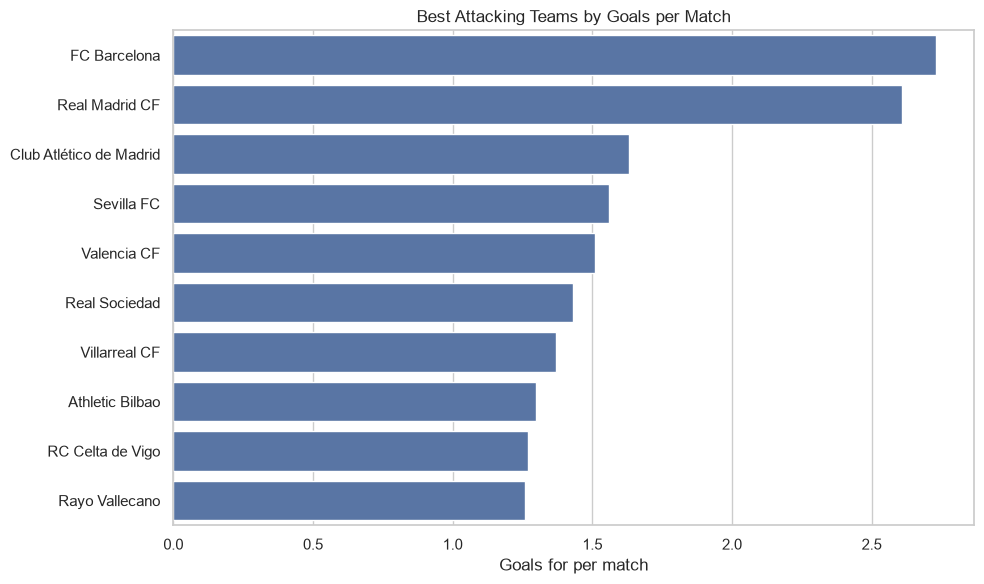

In [42]:
top_attack = (
    attack_summary
    .loc[attack_summary["seasons_played"] >= 3]
    .sort_values("goals_for_per_match", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_attack,
    x="goals_for_per_match",
    y="team_official",
    order=top_attack["team_official"],
    color=BAR_COLOR
)
plt.title("Best Attacking Teams by Goals per Match")
plt.xlabel("Goals for per match")
plt.ylabel("")
plt.tight_layout()
save_current_figure("best_attacking_teams_goals_per_match.png")
plt.show()

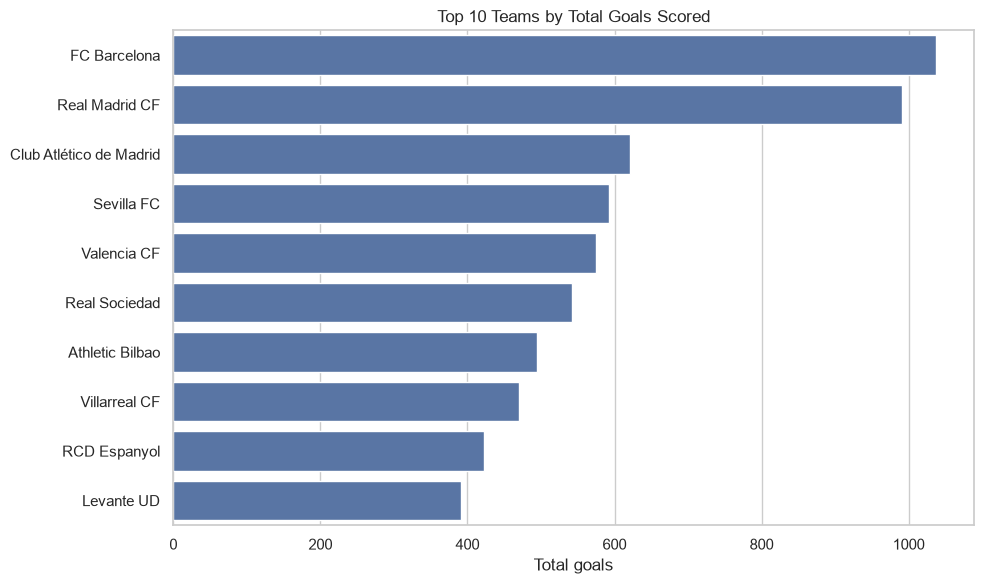

In [43]:
top_total_goals = (
    attack_summary
    .sort_values("goals_for", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_total_goals,
    x="goals_for",
    y="team_official",
    order=top_total_goals["team_official"],
    color=BAR_COLOR
)
plt.title("Top 10 Teams by Total Goals Scored")
plt.xlabel("Total goals")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Home vs away attacking output

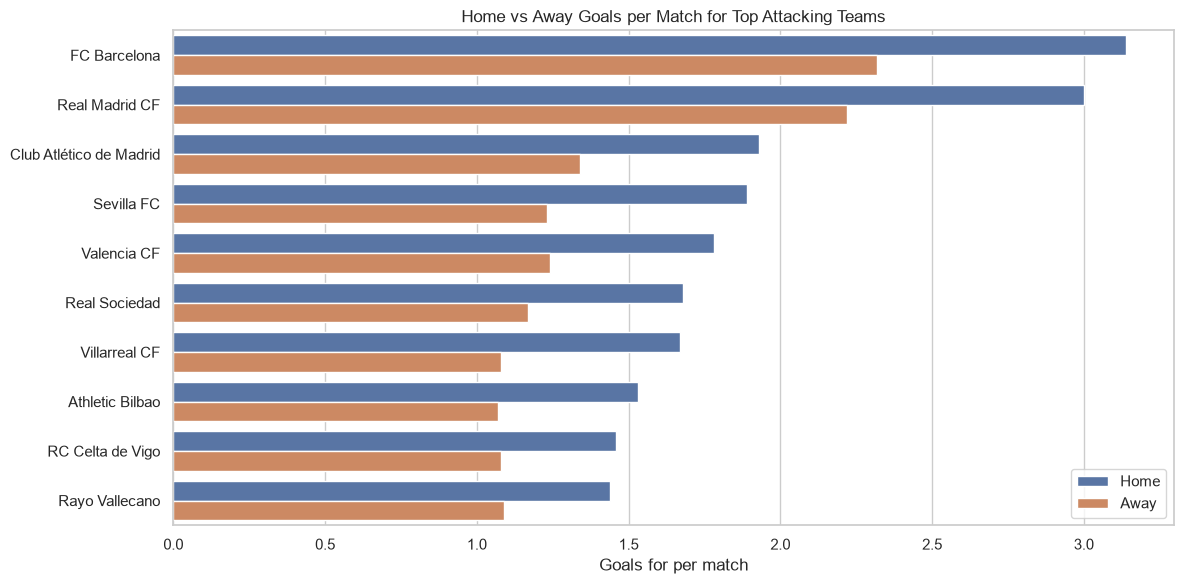

In [44]:
attack_top_teams = (
    attack_summary
    .loc[attack_summary["seasons_played"] >= 3]
    .sort_values("goals_for_per_match", ascending=False)
    .head(10)
)

attack_order = attack_top_teams["team_official"].tolist()

attack_home_away_plot = attack_top_teams[
    [
        "team_official",
        "home_goals_for_per_match",
        "away_goals_for_per_match",
    ]
].melt(
    id_vars="team_official",
    value_vars=[
        "home_goals_for_per_match",
        "away_goals_for_per_match",
    ],
    var_name="venue_metric",
    value_name="goals_per_match",
)

attack_home_away_plot["venue"] = attack_home_away_plot["venue_metric"].map(
    {
        "home_goals_for_per_match": "Home",
        "away_goals_for_per_match": "Away",
    }
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=attack_home_away_plot,
    x="goals_per_match",
    y="team_official",
    hue="venue",
    order=attack_order,
    palette="deep"
)
plt.title("Home vs Away Goals per Match for Top Attacking Teams")
plt.xlabel("Goals for per match")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

### Best attacking single seasons

In [45]:
best_attacking_seasons = (
    team_season_stats
    .sort_values(
        ["goals_for", "goal_difference", "points"],
        ascending=[False, False, False]
    )
    .head(10)
    [
        [
            "season",
            "team_official",
            "goals_for",
            "goals_for_per_match",
            "points",
            "wins",
            "goal_difference",
        ]
    ]
    .reset_index(drop=True)
)

best_attacking_seasons

,season,team_official,goals_for,goals_for_per_match,points,wins,goal_difference
0,2011-12,Real Madrid CF,121,3.18,100,32,89
1,2014-15,Real Madrid CF,118,3.11,92,30,80
2,2016-17,FC Barcelona,116,3.05,90,28,79
3,2012-13,FC Barcelona,115,3.03,100,32,75
4,2011-12,FC Barcelona,114,3.00,91,28,85
5,2015-16,FC Barcelona,112,2.95,91,29,83
6,2014-15,FC Barcelona,110,2.89,94,30,89
7,2015-16,Real Madrid CF,110,2.89,90,28,76
8,2016-17,Real Madrid CF,106,2.79,93,29,65
9,2013-14,Real Madrid CF,104,2.74,87,27,66


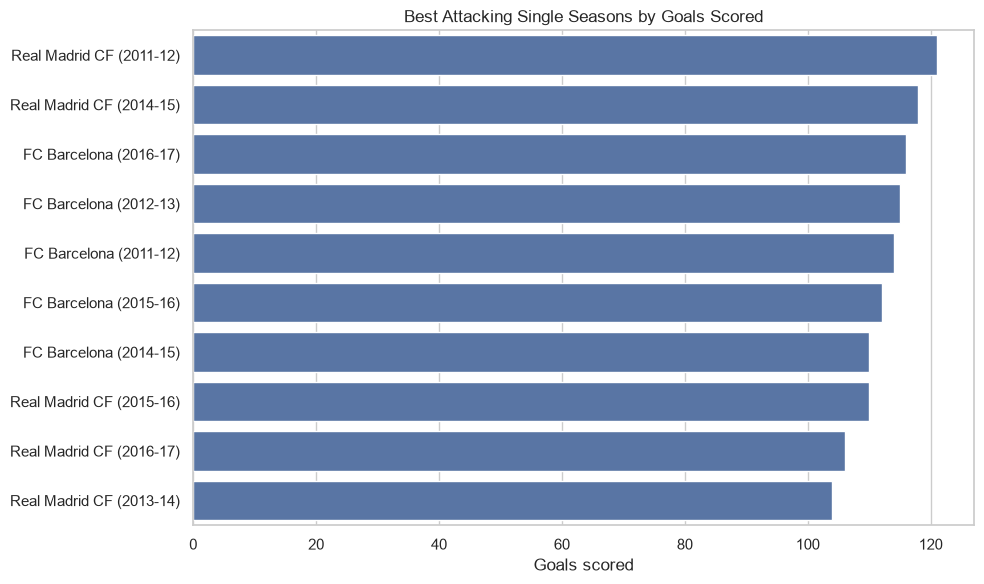

In [46]:
plot_data = best_attacking_seasons.copy()
plot_data["label"] = (
    plot_data["team_official"]
    + " ("
    + plot_data["season"]
    + ")"
)
plot_data = plot_data.sort_values("goals_for", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="goals_for",
    y="label",
    order=plot_data["label"],
    color=BAR_COLOR
)
plt.title("Best Attacking Single Seasons by Goals Scored")
plt.xlabel("Goals scored")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Analyst Comment

Goals per match is the most useful attacking metric for comparing teams across different numbers of seasons. Total goals still matter, but they are strongly affected by how many seasons a team played in La Liga.

The single-season ranking captures peak attacking output, while the decade-level ranking captures sustained attacking strength.

## Defensive Performance & Clean Sheets

This section analyzes defensive strength using goals conceded per match, clean sheets and clean sheet rate.

**Ranking direction matters here:** lower goals conceded is better. Defensive charts based on goals against are therefore ordered from the lowest value (best) to the highest value.

In [47]:
defense_summary = (
    team_season_stats
    .groupby(["team", "team_official"], as_index=False)
    .agg(
        seasons_played=("season", "nunique"),
        matches=("matches", "sum"),
        home_matches=("home_matches", "sum"),
        away_matches=("away_matches", "sum"),
        goals_against=("goals_against", "sum"),
        home_goals_against=("home_goals_against", "sum"),
        away_goals_against=("away_goals_against", "sum"),
        clean_sheets=("clean_sheets", "sum"),
        home_clean_sheets=("home_clean_sheets", "sum"),
        away_clean_sheets=("away_clean_sheets", "sum"),
        min_goals_against_in_season=("goals_against", "min"),
        max_clean_sheets_in_season=("clean_sheets", "max"),
    )
)

defense_summary["goals_against_per_match"] = (
    defense_summary["goals_against"] / defense_summary["matches"]
).round(2)

defense_summary["home_goals_against_per_match"] = (
    defense_summary["home_goals_against"] / defense_summary["home_matches"]
).round(2)

defense_summary["away_goals_against_per_match"] = (
    defense_summary["away_goals_against"] / defense_summary["away_matches"]
).round(2)

defense_summary["clean_sheet_rate"] = (
    defense_summary["clean_sheets"] / defense_summary["matches"] * 100
).round(1)

defense_summary["home_clean_sheet_rate"] = (
    defense_summary["home_clean_sheets"] / defense_summary["home_matches"] * 100
).round(1)

defense_summary["away_clean_sheet_rate"] = (
    defense_summary["away_clean_sheets"] / defense_summary["away_matches"] * 100
).round(1)

defense_summary = defense_summary.sort_values(
    "goals_against_per_match",
    ascending=True
).reset_index(drop=True)

defense_summary.head(15)

,team,team_official,seasons_played,matches,home_matches,away_matches,goals_against,home_goals_against,away_goals_against,clean_sheets,home_clean_sheets,away_clean_sheets,min_goals_against_in_season,max_clean_sheets_in_season,goals_against_per_match,home_goals_against_per_match,away_goals_against_per_match,clean_sheet_rate,home_clean_sheet_rate,away_clean_sheet_rate
0,Ath Madrid,Club Atlético de Madrid,10,380,190,190,308,120,188,189,108,81,18,24,0.81,0.63,0.99,49.7,56.8,42.6
1,Barcelona,FC Barcelona,10,380,190,190,313,137,176,169,89,80,21,23,0.82,0.72,0.93,44.5,46.8,42.1
2,Real Madrid,Real Madrid CF,10,380,190,190,373,166,207,137,79,58,25,19,0.98,0.87,1.09,36.1,41.6,30.5
3,Villarreal,Villarreal CF,9,342,171,171,397,175,222,115,60,55,33,17,1.16,1.02,1.30,33.6,35.1,32.2
4,Valencia,Valencia CF,10,380,190,190,466,199,267,107,68,39,32,14,1.23,1.05,1.41,28.2,35.8,20.5
5,Ath Bilbao,Athletic Bilbao,10,380,190,190,472,190,282,109,67,42,38,14,1.24,1.00,1.48,28.7,35.3,22.1
6,Sevilla,Sevilla FC,10,380,190,190,497,200,297,119,76,43,34,17,1.31,1.05,1.56,31.3,40.0,22.6
7,Leganes,CD Leganés,4,152,76,76,200,84,116,45,30,15,43,14,1.32,1.11,1.53,29.6,39.5,19.7
8,Alaves,Deportivo Alavés,4,152,76,76,202,82,120,41,26,15,43,12,1.33,1.08,1.58,27.0,34.2,19.7
9,Getafe,Getafe CF,9,342,171,171,458,180,278,94,62,32,33,15,1.34,1.05,1.63,27.5,36.3,18.7


### Best defensive teams by goals conceded per match

Saved figure: outputs/figures/best_defensive_teams_goals_conceded_per_match.png


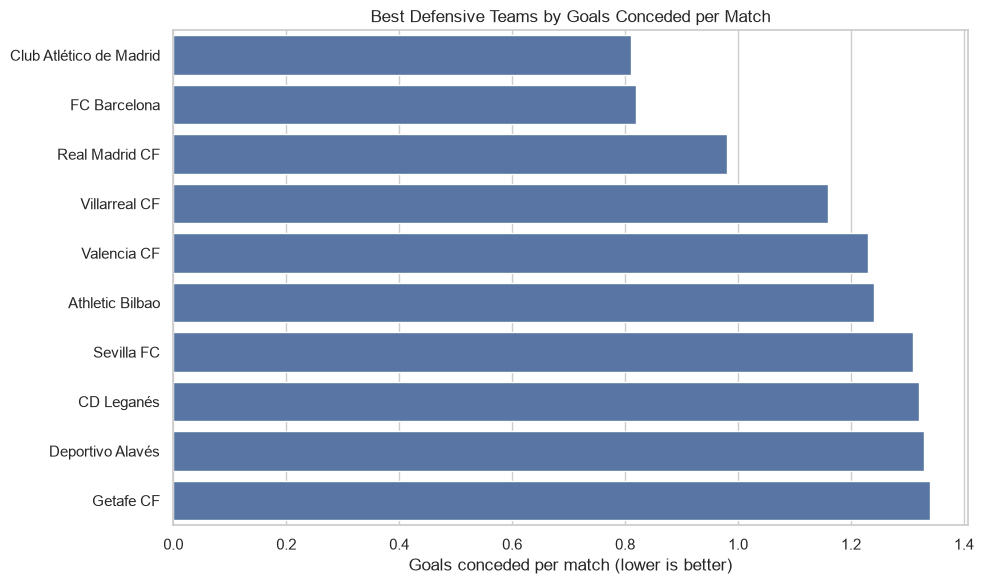

In [48]:
best_defense = (
    defense_summary
    .loc[defense_summary["seasons_played"] >= 3]
    .sort_values("goals_against_per_match", ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=best_defense,
    x="goals_against_per_match",
    y="team_official",
    order=best_defense["team_official"],
    color=BAR_COLOR
)
plt.title("Best Defensive Teams by Goals Conceded per Match")
plt.xlabel("Goals conceded per match (lower is better)")
plt.ylabel("")
plt.tight_layout()
save_current_figure("best_defensive_teams_goals_conceded_per_match.png")
plt.show()

### Best teams by clean sheet rate

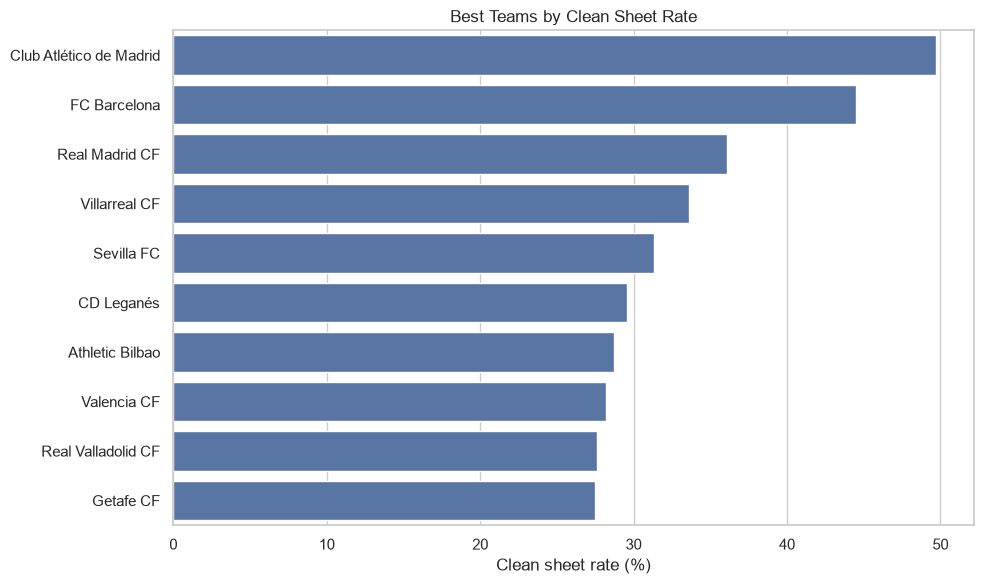

In [49]:
top_clean_sheet_rate = (
    defense_summary
    .loc[defense_summary["seasons_played"] >= 3]
    .sort_values("clean_sheet_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_clean_sheet_rate,
    x="clean_sheet_rate",
    y="team_official",
    order=top_clean_sheet_rate["team_official"],
    color=BAR_COLOR
)
plt.title("Best Teams by Clean Sheet Rate")
plt.xlabel("Clean sheet rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

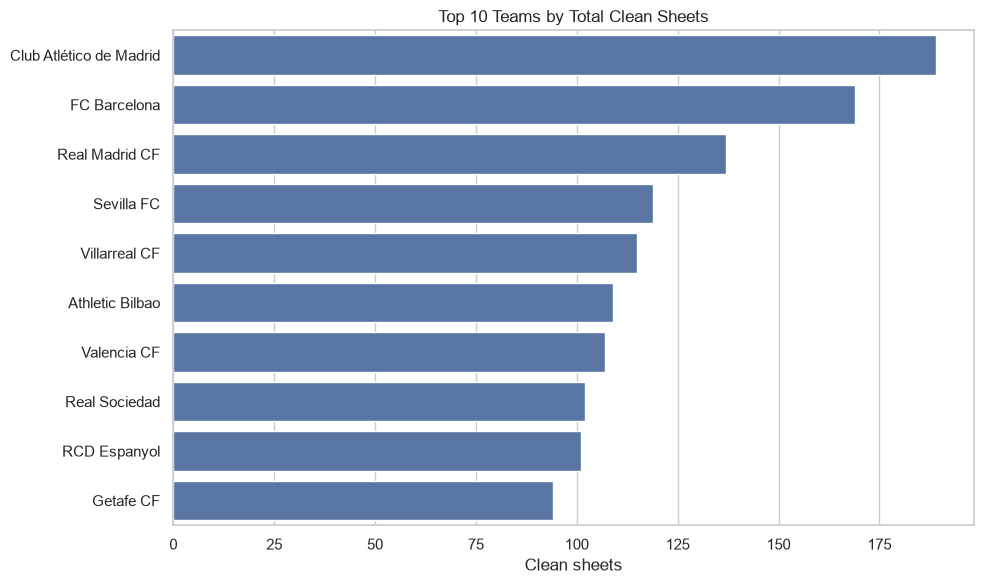

In [50]:
top_total_clean_sheets = (
    defense_summary
    .sort_values("clean_sheets", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_total_clean_sheets,
    x="clean_sheets",
    y="team_official",
    order=top_total_clean_sheets["team_official"],
    color=BAR_COLOR
)
plt.title("Top 10 Teams by Total Clean Sheets")
plt.xlabel("Clean sheets")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Home vs away clean sheet rate

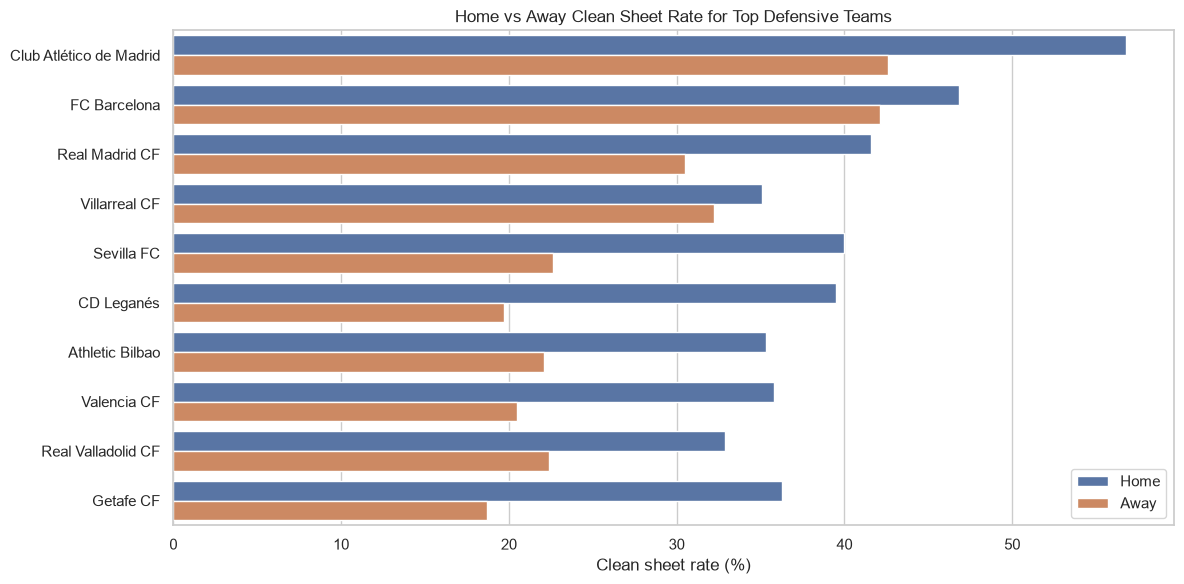

In [51]:
defense_top_teams = (
    defense_summary
    .loc[defense_summary["seasons_played"] >= 3]
    .sort_values("clean_sheet_rate", ascending=False)
    .head(10)
)

defense_order = defense_top_teams["team_official"].tolist()

clean_sheet_home_away_plot = defense_top_teams[
    [
        "team_official",
        "home_clean_sheet_rate",
        "away_clean_sheet_rate",
    ]
].melt(
    id_vars="team_official",
    value_vars=[
        "home_clean_sheet_rate",
        "away_clean_sheet_rate",
    ],
    var_name="venue_metric",
    value_name="clean_sheet_rate",
)

clean_sheet_home_away_plot["venue"] = clean_sheet_home_away_plot["venue_metric"].map(
    {
        "home_clean_sheet_rate": "Home",
        "away_clean_sheet_rate": "Away",
    }
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=clean_sheet_home_away_plot,
    x="clean_sheet_rate",
    y="team_official",
    hue="venue",
    order=defense_order,
    palette="deep"
)
plt.title("Home vs Away Clean Sheet Rate for Top Defensive Teams")
plt.xlabel("Clean sheet rate (%)")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

### Best defensive single seasons

In [52]:
best_defensive_seasons = (
    team_season_stats
    .sort_values(
        ["goals_against", "clean_sheets", "points"],
        ascending=[True, False, False]
    )
    .head(10)
    [
        [
            "season",
            "team_official",
            "goals_against",
            "goals_against_per_match",
            "clean_sheets",
            "points",
            "goal_difference",
        ]
    ]
    .reset_index(drop=True)
)

best_defensive_seasons

,season,team_official,goals_against,goals_against_per_match,clean_sheets,points,goal_difference
0,2015-16,Club Atlético de Madrid,18,0.47,24,88,45
1,2014-15,FC Barcelona,21,0.55,23,94,89
2,2010-11,FC Barcelona,21,0.55,19,96,74
3,2017-18,Club Atlético de Madrid,22,0.58,23,79,36
4,2019-20,Real Madrid CF,25,0.66,19,87,45
5,2013-14,Club Atlético de Madrid,26,0.68,20,90,51
6,2016-17,Club Atlético de Madrid,27,0.71,20,78,43
7,2019-20,Club Atlético de Madrid,27,0.71,17,70,24
8,2018-19,Club Atlético de Madrid,29,0.76,20,76,26
9,2017-18,FC Barcelona,29,0.76,19,93,70


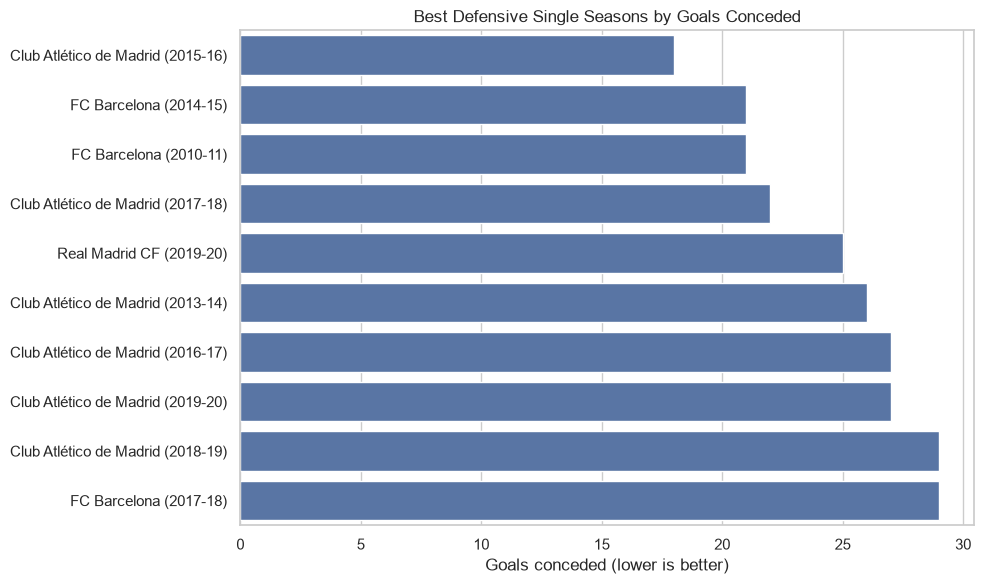

In [53]:
plot_data = best_defensive_seasons.copy()
plot_data["label"] = (
    plot_data["team_official"]
    + " ("
    + plot_data["season"]
    + ")"
)

# Lower goals conceded is better, so the best defensive season appears first.
plot_data = plot_data.sort_values("goals_against", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="goals_against",
    y="label",
    order=plot_data["label"],
    color=BAR_COLOR
)
plt.title("Best Defensive Single Seasons by Goals Conceded")
plt.xlabel("Goals conceded (lower is better)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Analyst Comment

Goals conceded per match and clean sheet rate capture different aspects of defensive performance. A team can concede relatively few goals without keeping the highest number of clean sheets, so both metrics are useful.

For all goals-against rankings, **lower values represent stronger defensive performance**.

## Best Single Seasons

This section ranks the strongest individual team seasons in the dataset. Points are the primary ranking metric, followed by goal difference and goals scored.

In [54]:
best_single_seasons = (
    team_season_stats
    .sort_values(
        ["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    )
    .head(15)
    [
        [
            "season",
            "team_official",
            "points",
            "wins",
            "draws",
            "losses",
            "goals_for",
            "goals_against",
            "goal_difference",
            "clean_sheets",
        ]
    ]
    .reset_index(drop=True)
)

best_single_seasons

,season,team_official,points,wins,draws,losses,goals_for,goals_against,goal_difference,clean_sheets
0,2011-12,Real Madrid CF,100,32,4,2,121,32,89,14
1,2012-13,FC Barcelona,100,32,4,2,115,40,75,10
2,2010-11,FC Barcelona,96,30,6,2,95,21,74,19
3,2014-15,FC Barcelona,94,30,4,4,110,21,89,23
4,2017-18,FC Barcelona,93,28,9,1,99,29,70,19
5,2016-17,Real Madrid CF,93,29,6,3,106,41,65,10
6,2014-15,Real Madrid CF,92,30,2,6,118,38,80,15
7,2010-11,Real Madrid CF,92,29,5,4,102,33,69,16
8,2011-12,FC Barcelona,91,28,7,3,114,29,85,19
9,2015-16,FC Barcelona,91,29,4,5,112,29,83,18


Saved figure: outputs/figures/best_single_seasons_by_points.png


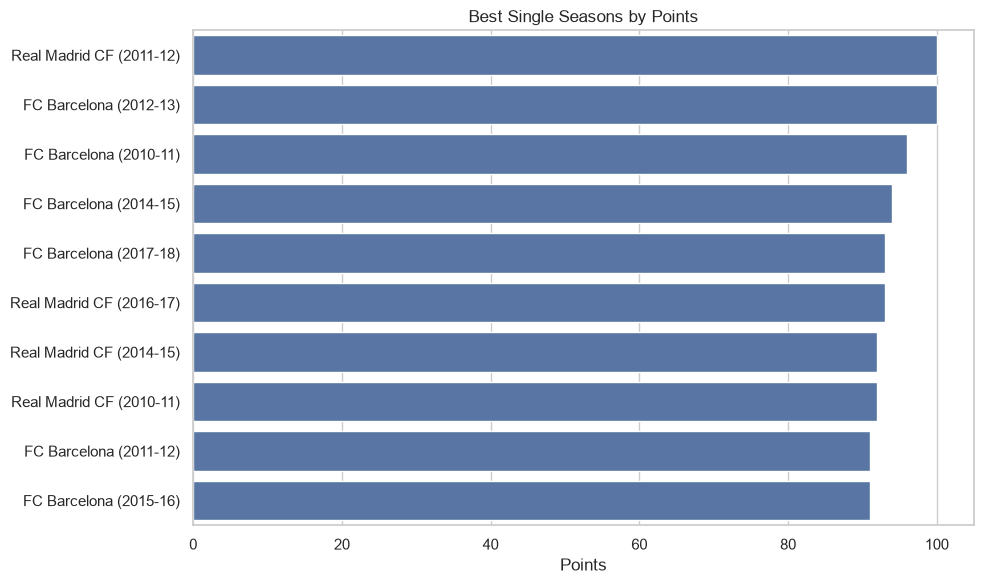

In [55]:
plot_data = best_single_seasons.head(10).copy()
plot_data["label"] = (
    plot_data["team_official"]
    + " ("
    + plot_data["season"]
    + ")"
)
plot_data = plot_data.sort_values("points", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="points",
    y="label",
    order=plot_data["label"],
    color=BAR_COLOR
)
plt.title("Best Single Seasons by Points")
plt.xlabel("Points")
plt.ylabel("")
plt.tight_layout()
save_current_figure("best_single_seasons_by_points.png")
plt.show()

In [56]:
best_gd_seasons = (
    team_season_stats
    .sort_values(
        ["goal_difference", "points", "goals_for"],
        ascending=[False, False, False]
    )
    .head(10)
    [
        [
            "season",
            "team_official",
            "goal_difference",
            "points",
            "goals_for",
            "goals_against",
            "clean_sheets",
        ]
    ]
    .reset_index(drop=True)
)

best_gd_seasons

,season,team_official,goal_difference,points,goals_for,goals_against,clean_sheets
0,2011-12,Real Madrid CF,89,100,121,32,14
1,2014-15,FC Barcelona,89,94,110,21,23
2,2011-12,FC Barcelona,85,91,114,29,19
3,2015-16,FC Barcelona,83,91,112,29,18
4,2014-15,Real Madrid CF,80,92,118,38,15
5,2016-17,FC Barcelona,79,90,116,37,13
6,2015-16,Real Madrid CF,76,90,110,34,14
7,2012-13,FC Barcelona,75,100,115,40,10
8,2010-11,FC Barcelona,74,96,95,21,19
9,2017-18,FC Barcelona,70,93,99,29,19


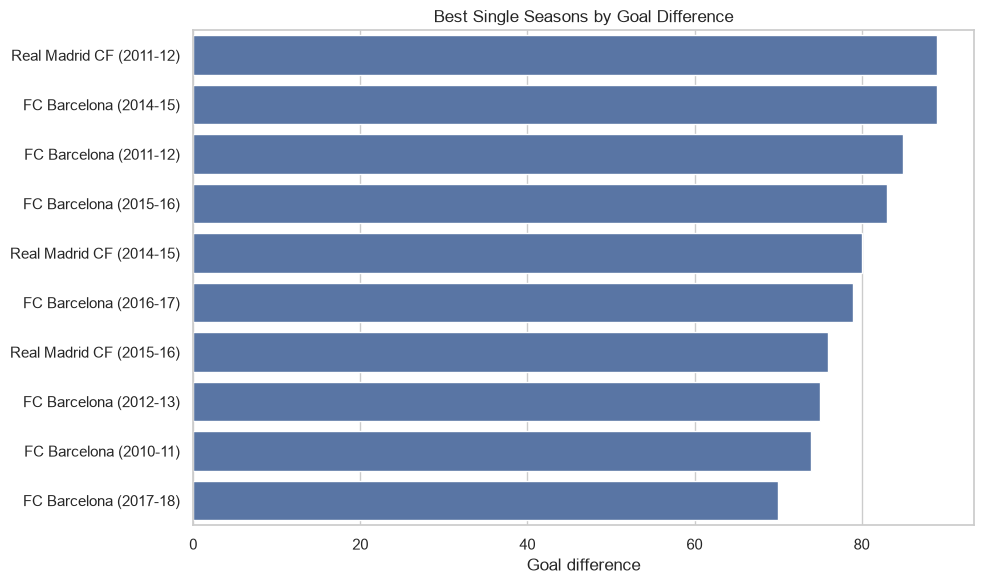

In [57]:
plot_data = best_gd_seasons.copy()
plot_data["label"] = (
    plot_data["team_official"]
    + " ("
    + plot_data["season"]
    + ")"
)
plot_data = plot_data.sort_values("goal_difference", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="goal_difference",
    y="label",
    order=plot_data["label"],
    color=BAR_COLOR
)
plt.title("Best Single Seasons by Goal Difference")
plt.xlabel("Goal difference")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [58]:
balanced_elite_seasons = (
    team_season_stats
    .assign(
        clean_sheet_rate=lambda x: (
            x["clean_sheets"] / x["matches"] * 100
        ).round(1)
    )
    .sort_values(
        [
            "points",
            "goal_difference",
            "goals_for",
            "clean_sheet_rate",
        ],
        ascending=[False, False, False, False]
    )
    .head(15)
    [
        [
            "season",
            "team_official",
            "points",
            "goal_difference",
            "goals_for",
            "goals_against",
            "clean_sheets",
            "clean_sheet_rate",
        ]
    ]
    .reset_index(drop=True)
)

balanced_elite_seasons

,season,team_official,points,goal_difference,goals_for,goals_against,clean_sheets,clean_sheet_rate
0,2011-12,Real Madrid CF,100,89,121,32,14,36.8
1,2012-13,FC Barcelona,100,75,115,40,10,26.3
2,2010-11,FC Barcelona,96,74,95,21,19,50.0
3,2014-15,FC Barcelona,94,89,110,21,23,60.5
4,2017-18,FC Barcelona,93,70,99,29,19,50.0
5,2016-17,Real Madrid CF,93,65,106,41,10,26.3
6,2014-15,Real Madrid CF,92,80,118,38,15,39.5
7,2010-11,Real Madrid CF,92,69,102,33,16,42.1
8,2011-12,FC Barcelona,91,85,114,29,19,50.0
9,2015-16,FC Barcelona,91,83,112,29,18,47.4


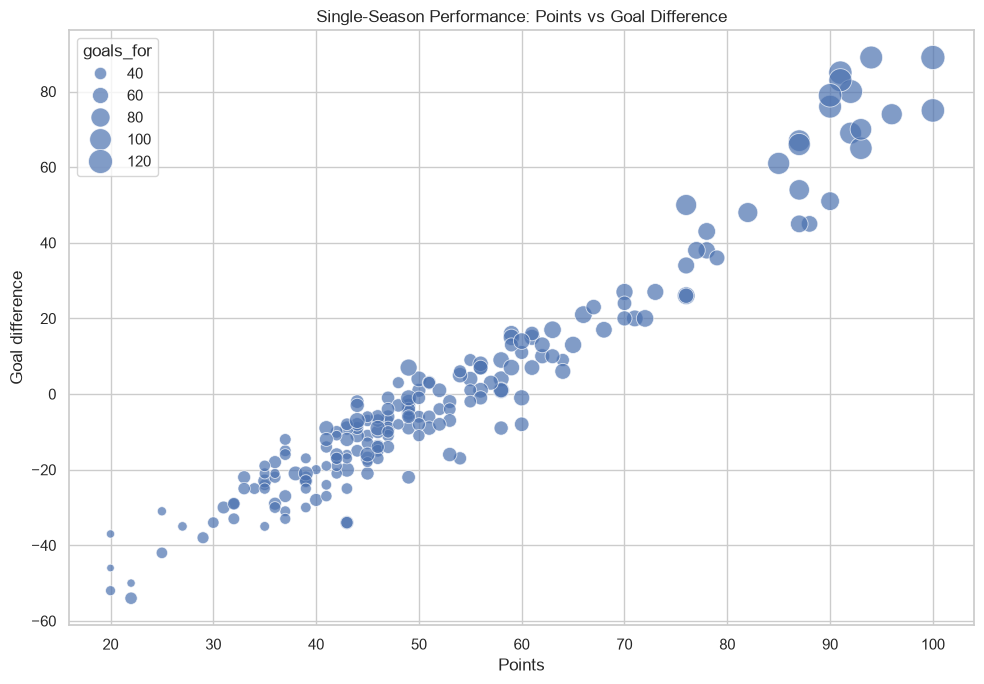

In [59]:
single_season_scatter = team_season_stats.copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=single_season_scatter,
    x="points",
    y="goal_difference",
    size="goals_for",
    sizes=(30, 300),
    alpha=0.7,
    color=BAR_COLOR
)
plt.title("Single-Season Performance: Points vs Goal Difference")
plt.xlabel("Points")
plt.ylabel("Goal difference")
plt.tight_layout()
plt.show()

### Analyst Comment

The best single-season rankings highlight peak performance rather than long-term consistency. Points provide the primary view, while goal difference helps distinguish dominant seasons from merely efficient ones.

The points-versus-goal-difference relationship also shows how closely league success is connected with scoring dominance.

## Key Findings

The following summary is generated directly from the analytical tables so that the headline findings remain reproducible.

In [60]:
top_total_points_team = decade_points.iloc[0]
top_avg_points_team = avg_points_ranking.iloc[0]
best_home_team = best_home_teams.iloc[0]
best_away_team = best_away_teams.iloc[0]
best_attack_team = (
    attack_summary
    .loc[attack_summary["seasons_played"] >= 3]
    .sort_values("goals_for_per_match", ascending=False)
    .iloc[0]
)
best_defense_team = (
    defense_summary
    .loc[defense_summary["seasons_played"] >= 3]
    .sort_values("goals_against_per_match", ascending=True)
    .iloc[0]
)
best_clean_sheet_team = (
    defense_summary
    .loc[defense_summary["seasons_played"] >= 3]
    .sort_values("clean_sheet_rate", ascending=False)
    .iloc[0]
)
best_single_season = best_single_seasons.iloc[0]

key_findings = [
    {
        "finding": "Most total points",
        "team": top_total_points_team["team_official"],
        "value": int(top_total_points_team["total_points"]),
    },
    {
        "finding": "Highest average points per season",
        "team": top_avg_points_team["team_official"],
        "value": round(top_avg_points_team["avg_points_per_season"], 2),
    },
    {
        "finding": "Best home team by PPM",
        "team": best_home_team["team_official"],
        "value": round(best_home_team["home_ppm"], 2),
    },
    {
        "finding": "Best away team by PPM",
        "team": best_away_team["team_official"],
        "value": round(best_away_team["away_ppm"], 2),
    },
    {
        "finding": "Best attack by goals per match",
        "team": best_attack_team["team_official"],
        "value": round(best_attack_team["goals_for_per_match"], 2),
    },
    {
        "finding": "Best defense by goals conceded per match",
        "team": best_defense_team["team_official"],
        "value": round(best_defense_team["goals_against_per_match"], 2),
    },
    {
        "finding": "Best clean sheet rate",
        "team": best_clean_sheet_team["team_official"],
        "value": f'{best_clean_sheet_team["clean_sheet_rate"]}%',
    },
    {
        "finding": "Best single season by points",
        "team": f'{best_single_season["team_official"]} ({best_single_season["season"]})',
        "value": int(best_single_season["points"]),
    },
]

key_findings_df = pd.DataFrame(key_findings)
key_findings_df

,finding,team,value
0,Most total points,FC Barcelona,911
1,Highest average points per season,FC Barcelona,91.1
2,Best home team by PPM,FC Barcelona,2.64
3,Best away team by PPM,FC Barcelona,2.15
4,Best attack by goals per match,FC Barcelona,2.73
5,Best defense by goals conceded per match,Club Atlético de Madrid,0.81
6,Best clean sheet rate,Club Atlético de Madrid,49.7%
7,Best single season by points,Real Madrid CF (2011-12),100


### Summary

The report combines long-term dominance, per-match efficiency, venue splits and single-season peaks. This avoids relying on one metric only: totals capture sustained presence, while per-match/per-season measures improve comparisons across teams with different numbers of seasons played.

## Limitations & Next Steps

### Current limitations

- Standings positions are currently calculated using points, overall goal difference and goals scored.
- Official La Liga head-to-head tie-breakers are not yet implemented.
- The analysis focuses on score-based metrics only; shots, shots on target, cards and corners are intentionally outside the core scope.
- Some long-term team rankings use a minimum threshold of 3 seasons played to reduce small-sample effects.
- Team logos are not yet included in the charts.

### Possible future enhancements

- Implement official-style La Liga head-to-head tie-breakers and validate the calculated final positions against official standings.
- Add a reusable head-to-head mini-table function for two or more teams.
- Add overall, home and away form metrics.
- Add winning, losing, unbeaten and winless streak analysis.
- Add optional team logos to selected portfolio visualizations.
- Extend the project into predictive modeling.

### Export key analytical tables

In [61]:
key_findings_df.to_csv(
    TABLES_DIR / "key_findings.csv",
    index=False
)

decade_points.to_csv(
    TABLES_DIR / "decade_points_summary.csv",
    index=False
)

home_away_summary.to_csv(
    TABLES_DIR / "home_away_summary.csv",
    index=False
)

attack_summary.to_csv(
    TABLES_DIR / "attack_summary.csv",
    index=False
)

defense_summary.to_csv(
    TABLES_DIR / "defense_summary.csv",
    index=False
)

print("Saved key output tables.")

Saved key output tables.


In [62]:
report_status = pd.DataFrame(
    {
        "section": [
            "Dataset overview",
            "Decade overview",
            "Scoreline analysis",
            "Team dominance",
            "Consistency",
            "Home vs away",
            "Attacking performance",
            "Defensive performance",
            "Best single seasons",
            "Key findings",
            "Limitations",
        ],
        "status": ["Complete"] * 11,
    }
)

report_status

,section,status
0,Dataset overview,Complete
1,Decade overview,Complete
2,Scoreline analysis,Complete
3,Team dominance,Complete
4,Consistency,Complete
5,Home vs away,Complete
6,Attacking performance,Complete
7,Defensive performance,Complete
8,Best single seasons,Complete
9,Key findings,Complete
